In [1]:
# Import Required Libraries
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()

def bell_circuit(state="phi_plus", basis="computational"):
    qc = QuantumCircuit(2, 2)

    # Create Bell state from |00>
    if state == "phi_plus":
        qc.h(0)
        qc.cx(0, 1)

    elif state == "phi_minus":
        qc.h(0)
        qc.z(0)
        qc.cx(0, 1)

    elif state == "psi_plus":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)

    elif state == "psi_minus":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)

    else:
        raise ValueError("Use phi_plus, phi_minus, psi_plus, or psi_minus")

    # Hadamard basis measurement
    if basis == "hadamard":
        qc.h(0)
        qc.h(1)

    qc.measure([0, 1], [0, 1])
    return qc


def run_bell(state, basis="computational", shots=1024):
    qc = bell_circuit(state, basis)
    result = simulator.run(qc, shots=shots).result()
    return qc, result.get_counts()


bell_names = {
    "phi_plus": "|Φ+⟩",
    "phi_minus": "|Φ−⟩",
    "psi_plus": "|Ψ+⟩",
    "psi_minus": "|Ψ−⟩"
}


Qiskit Version: 2.5.1


GHZ circuit:
     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 

GHZ counts:
{'111': 2015, '000': 2081}

W-state circuit:
     ┌───────────┐           ┌───┐           ┌─┐           
q_0: ┤ Ry(1.231) ├─────■─────┤ X ├───────────┤M├───────────
     └───────────┘┌────┴────┐└─┬─┘           └╥┘┌───┐┌─┐   
q_1: ─────────────┤ Ry(π/2) ├──■───────■──────╫─┤ X ├┤M├───
                  └─────────┘     ┌────┴────┐ ║ └─┬─┘└╥┘┌─┐
q_2: ─────────────────────────────┤ Ry(π/2) ├─╫───■───╫─┤M├
                                  └─────────┘ ║       ║ └╥┘
c: 3/═════════════════════════════════════════╩═══════╩══╩═
                                              0       1  2 

W-state counts:
{'000': 2757, '100': 311, '010': 334, '001': 694}


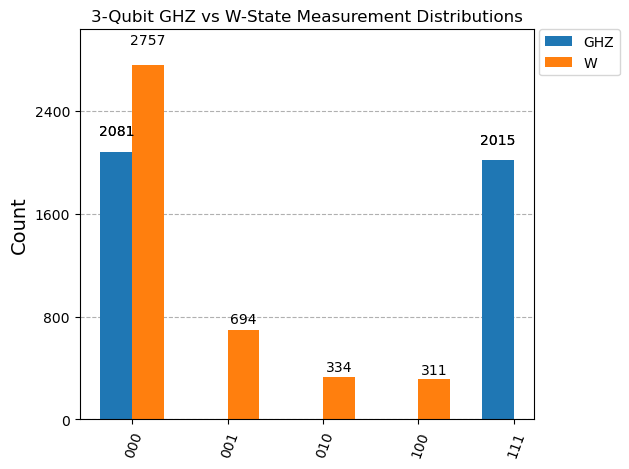

In [2]:
def ghz_circuit():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(0, 2)
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc


def w_state_circuit():
    # Prepare an approximate/exact 3-qubit W state using
    # controlled rotations and CNOT gates.
    qc = QuantumCircuit(3, 3)

    # First create:
    # cos(theta)|000> + sin(theta)|100>
    theta = 2 * np.arcsin(1 / np.sqrt(3))
    qc.ry(theta, 0)

    # Distribute the excitation.
    qc.cry(2 * np.arcsin(1 / np.sqrt(2)), 0, 1)
    qc.cx(1, 0)
    qc.cry(np.pi / 2, 1, 2)
    qc.cx(2, 1)

    qc.measure([0, 1, 2], [0, 1, 2])
    return qc


ghz = ghz_circuit()
w = w_state_circuit()

ghz_counts = simulator.run(ghz, shots=4096).result().get_counts()
w_counts = simulator.run(w, shots=4096).result().get_counts()

print("GHZ circuit:")
print(ghz)
print("\nGHZ counts:")
print(ghz_counts)

print("\nW-state circuit:")
print(w)
print("\nW-state counts:")
print(w_counts)

plot_histogram(
    [ghz_counts, w_counts],
    legend=["GHZ", "W"],
    title="3-Qubit GHZ vs W-State Measurement Distributions"
)
